In [36]:
import dataclasses
import glob
import itertools
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import scipy.stats

from lib.plots import attach_colorbar, set_axis
from lib.stats import fit_power_law

In [37]:
task_id = "4-params_sweep"

metrics_table = pl.read_csv(f"{task_id}/_outputs/metrics_table.csv")

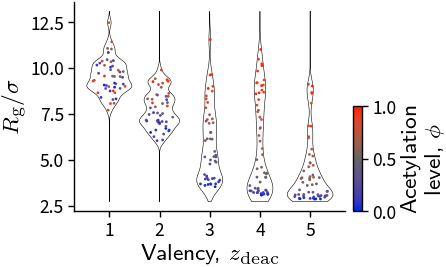

In [38]:
groups = {
    z: group
    for (z, ), group in (
        metrics_table
        .sort("association_valency")
        .group_by("association_valency", maintain_order=True)
    )
}

fig, ax = plt.subplots(figsize=(1.8, 1.4))

random = np.random.Generator(np.random.PCG64(0))
kde_bw = 0.25
x_scale = 1.0
y_min = metrics_table["rg_mean"].min() * 0.95
y_max = metrics_table["rg_mean"].max() * 1.05
c_min = 0
c_max = 1

sm_dots = plt.cm.ScalarMappable(
    norm=plt.cm.colors.Normalize(vmin=c_min, vmax=c_max),
    cmap=colorcet.m_CET_D8,
)

for z, group in groups.items():
    values = group["rg_mean"]

    kde = scipy.stats.gaussian_kde(values, bw_method=kde_bw)
    densities = kde(values)

    x = z + 0.8 * x_scale * densities * random.uniform(-1, 1, size=len(densities))
    y = values
    c = group["acetylation_level"]
    ax.scatter(x, y, c=c, s=1, edgecolor="none", norm=sm_dots.norm, cmap=sm_dots.cmap, zorder=3)

    y = np.linspace(y_min, y_max, num=100)
    dx = x_scale * kde(y)
    x1 = z - dx
    x2 = z + dx
    ax.fill_betweenx(y, x1, x2, edgecolor="k", facecolor="none", linewidth=0.2, zorder=2)

cbar = attach_colorbar(ax, sm_dots, length=0.5)
cbar.set_label("Acetylation\nlevel, " + r"$ \phi $", usetex=True)
cbar.solids.set_rasterized(False)

ax.set_xticks(np.arange(1, 6))
ax.set_xlabel("Valency, " + r"$ z_\mathrm{deac} $", usetex=True)
ax.set_ylabel(r"$ R_\mathrm{g}/\sigma $", usetex=True)

set_axis(ax, "left bottom")

fig.savefig("_figs/acetylated_chain-valency_phi.svg")

pass